In [1]:
import shutil
import os
source_directory = "archive/DATASET"
destination_directory = "waste_classification_data"

# Create the destination directory if it doesn't exist
if not os.path.exists(destination_directory):
    os.makedirs(destination_directory)

# Construct the full destination path
full_destination_path = os.path.join(destination_directory, "1") #Creates a folder called 1 inside the destination folder.

try:
    shutil.copytree(source_directory, full_destination_path)
    print(f"Directory copied to: {full_destination_path}")
except FileExistsError:
    print(f"Destination directory '{full_destination_path}' already exists.")
except FileNotFoundError:
    print(f"Source directory '{source_directory}' not found.")
except Exception as e:
    print(f"An error occurred: {e}")

Destination directory 'waste_classification_data\1' already exists.


In [6]:
!pip install numpy pandas matplotlib opencv-python tqdm ipykernel notebook cv2


Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement cv2 (from versions: none)
ERROR: No matching distribution found for cv2


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from tqdm.notebook import tqdm


ModuleNotFoundError: No module named 'numpy'

In [ ]:
BASE_PATH = "waste_classification_data/1/DATASET"
TRAIN_PATH = os.path.join(BASE_PATH, "TRAIN")
TEST_PATH = os.path.join(BASE_PATH, "TEST")

print("Train path:", TRAIN_PATH)
print("Exists?", os.path.exists(TRAIN_PATH))


Train path: waste_classification_data/1/DATASET\TRAIN
Exists? True


In [ ]:
x_data = []
y_data = []

categories = glob(TRAIN_PATH + "/*")

print("Categories found:", [os.path.basename(c) for c in categories])

for category in categories:
    label = os.path.basename(category)
    files = glob(category + "/*")

    for file in tqdm(files, desc=f"Loading {label}"):
        img = cv2.imread(file)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        x_data.append(img)
        y_data.append(label)

data = pd.DataFrame({
    "image": x_data,
    "label": y_data
})

print("Total images loaded:", len(data))


Categories found: ['O', 'R']


Loading O:   0%|          | 0/12565 [00:00<?, ?it/s]

Loading R:   0%|          | 0/9999 [00:00<?, ?it/s]

Total images loaded: 22564


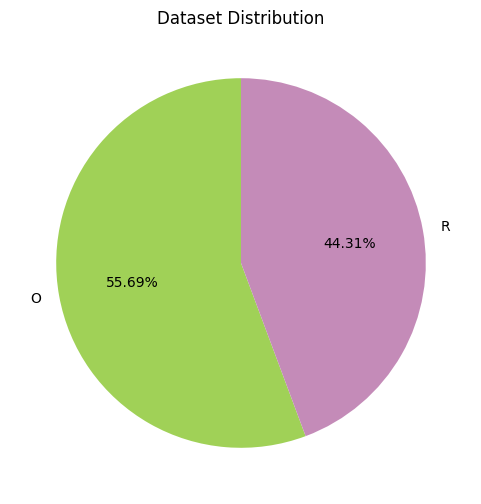

In [ ]:
if not data.empty:
    colors = ['#a0d157', '#c48bb8']

    plt.figure(figsize=(6,6))
    data.label.value_counts().plot(
        kind="pie",
        autopct="%0.2f%%",
        startangle=90,
        colors=colors
    )
    plt.ylabel("")
    plt.title("Dataset Distribution")
    plt.show()
else:
    print("Data is empty — cannot plot.")



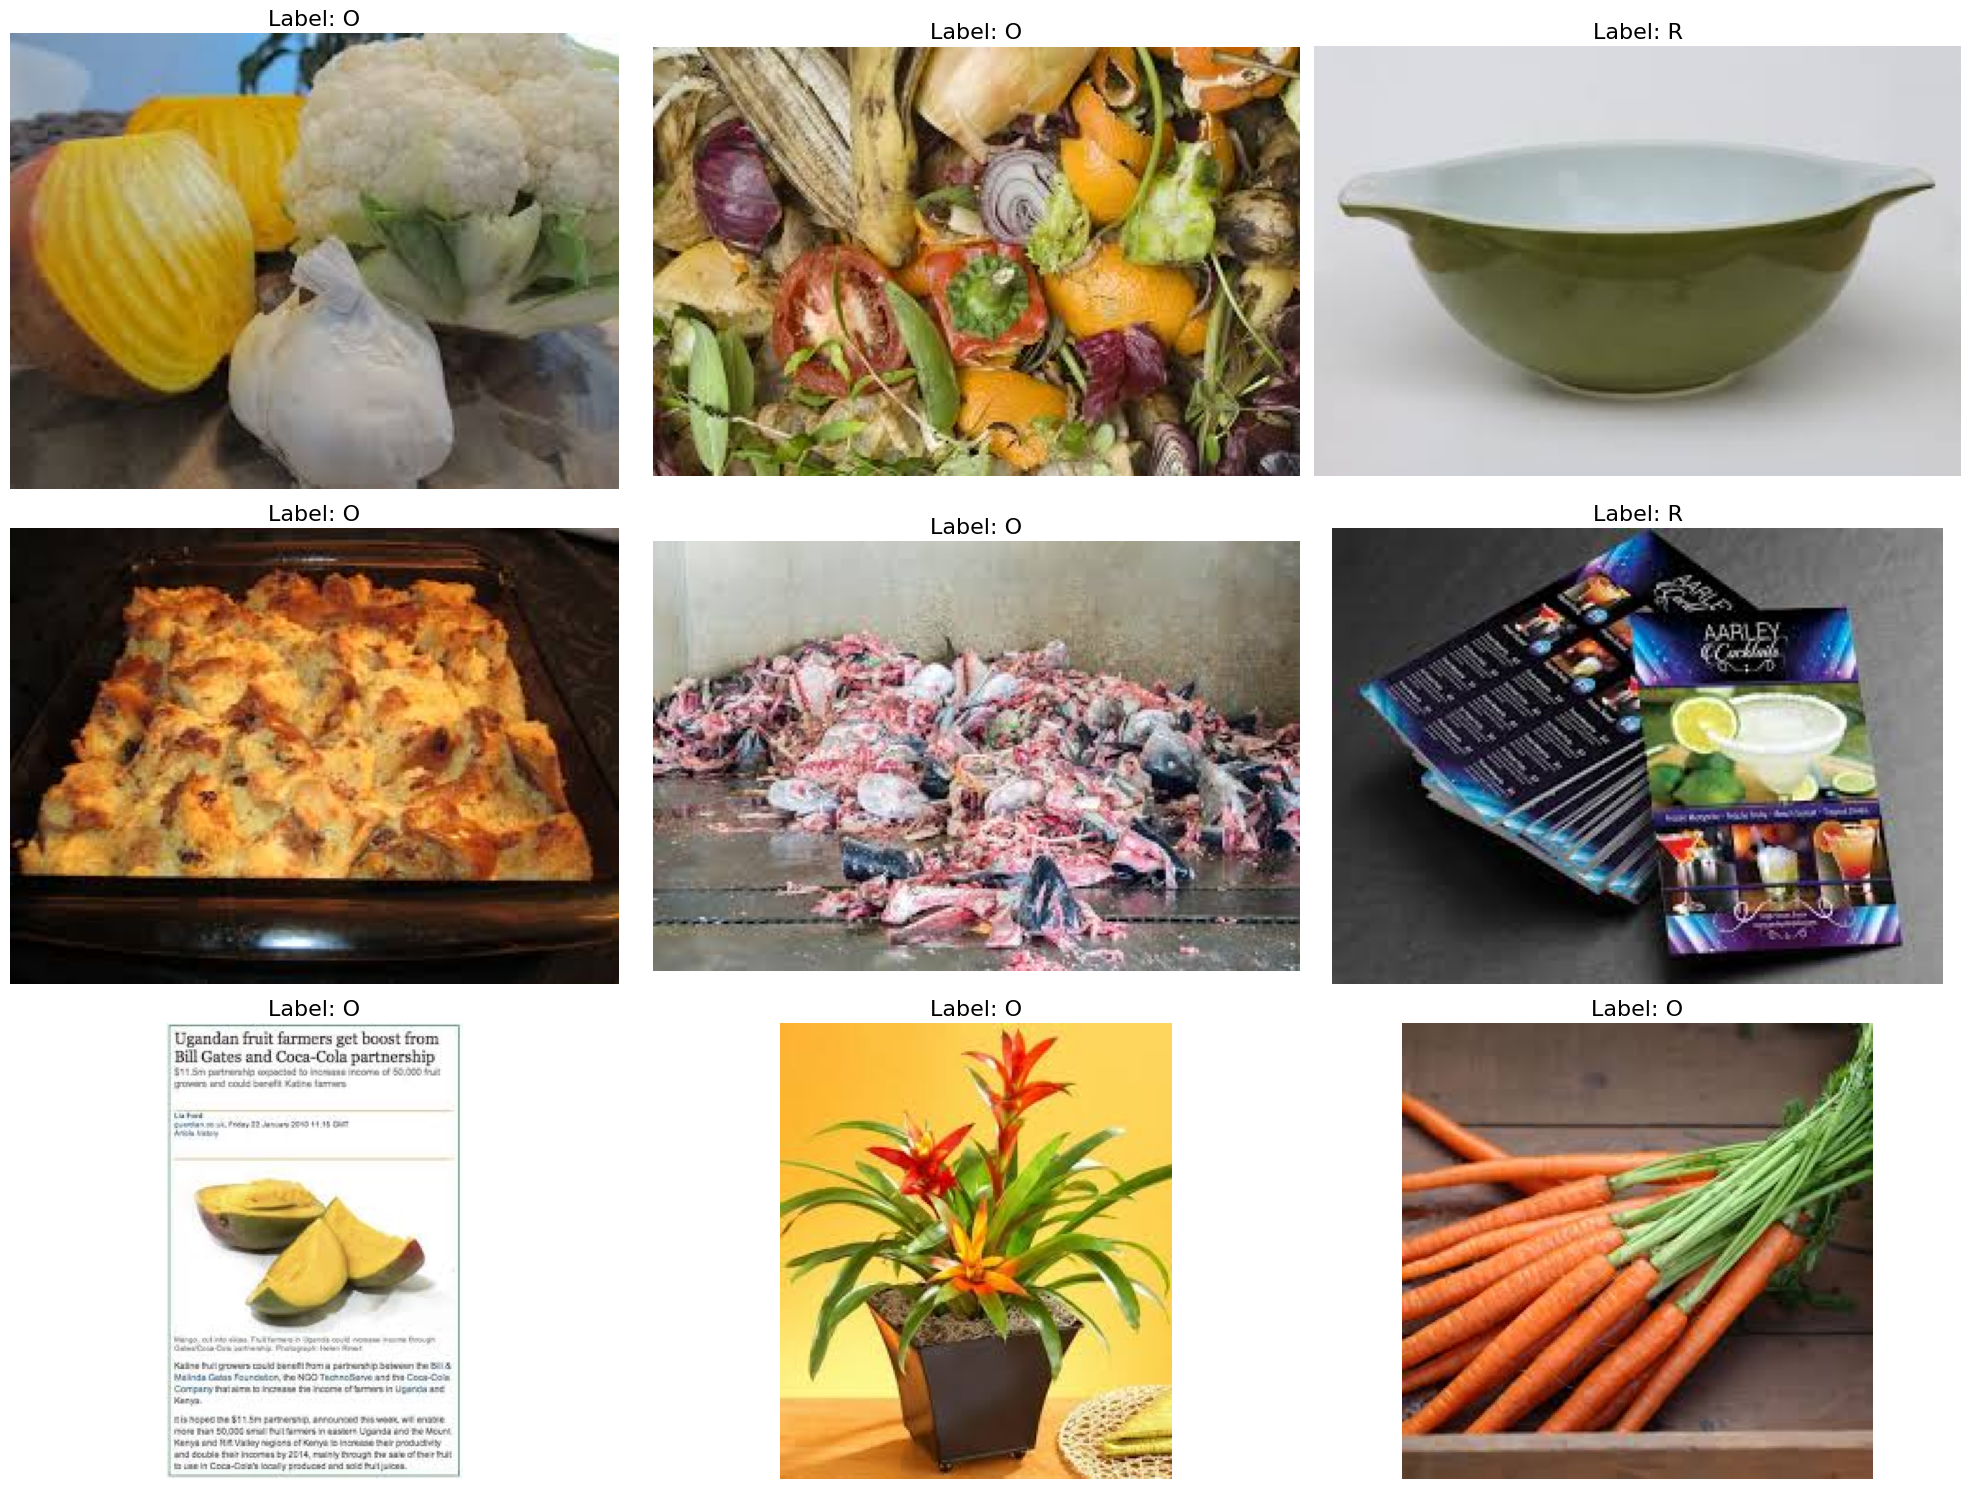

In [ ]:
plt.figure(figsize=(20,15))

max_index = len(data)

for i in range(9):
    idx = np.random.randint(max_index)
    plt.subplot(3,3,i+1)
    plt.title(f"Label: {data.label[idx]}", fontsize=16)
    plt.imshow(data.image[idx])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
!pip uninstall protobuf -y

!pip install protobuf==3.20.3


Found existing installation: protobuf 4.25.8
Uninstalling protobuf-4.25.8:
  Successfully uninstalled protobuf-4.25.8


You can safely remove it manually.


  Using cached protobuf-3.20.3-py2.py3-none-any.whl.metadata (720 bytes)
Using cached protobuf-3.20.3-py2.py3-none-any.whl (162 kB)


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.75.1 requires protobuf<7.0.0,>=6.31.1, but you have protobuf 3.20.3 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 3.20.3 which is incompatible.


In [ ]:
!conda create -n tf python=3.10 -y
!conda activate tf



^C
Failed to run 'conda activate tf'.



EnvironmentNameNotFound: Could not find conda environment: tf
You can list all discoverable environments with `conda info --envs`.




In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Activation, MaxPooling2D, Flatten, Dense, Dropout

numberOfClass = 2

model =  Sequential()

model.add(Conv2D(32, (3, 3), input_shape=(224,224, 3), padding='same' ))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), padding='same'))
model.add(Activation("relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Flatten())
model.add(Dense(128))
model.add(Activation("relu"))

model.add(Dropout(0.5))

model.add(Dense(numberOfClass))
model.add(Activation("sigmoid"))

model.summary()

ImportError: cannot import name 'runtime_version' from 'google.protobuf' (C:\Users\jadha\AppData\Roaming\Python\Python313\site-packages\google\protobuf\__init__.py)